![表紙](https://www.oreilly.co.jp/books/images/picture978-4-87311-907-6.gif)

このノートブックはオライリー・ジャパンより発行の書籍[『セキュリティエンジニアのための機械学習』](https://www.oreilly.co.jp/books/9784873119076/)のサンプルコードです。コードの解説等は書籍をご参照ください。なお、このコードを動作させた結果について、著者およびオライリー・ジャパンは一切の責任を負いません。

##ロジスティック回帰を使用したフィッシング検出器

In [2]:
!wget https://github.com/oreilly-japan/ml-security-jp/raw/master/ch02/dataset.csv

--2025-09-08 04:25:53--  https://github.com/oreilly-japan/ml-security-jp/raw/master/ch02/dataset.csv
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/oreilly-japan/ml-security-jp/master/ch02/dataset.csv [following]
--2025-09-08 04:25:53--  https://raw.githubusercontent.com/oreilly-japan/ml-security-jp/master/ch02/dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 788720 (770K) [text/plain]
Saving to: ‘dataset.csv’

dataset.csv         100%[===================>] 770.23K  --.-KB/s    in 0.04s   

2025-09-08 04:25:54 (19.4 MB/s) - ‘dataset.csv’ saved [788720/788720]



In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 13.7 MB/s eta 0:00:00


scikit learn機械学習用のモジュール

#2値分類
・2つの領域に分ける
・True Falseの判定


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import optuna
from sklearn.model_selection import cross_validate

training_data = np.genfromtxt('dataset.csv', delimiter=',', dtype=np.int32)

学習用にデータを0.2分割

In [5]:
X = training_data[:,:-1]
y = training_data[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=101)

classifier = LogisticRegression(solver='lbfgs')

# 訓練用データを使って検出器を訓練する。
classifier.fit(X_train, y_train)
# 予測させる。
predictions = classifier.predict(X_test)

# このフィッシング検出器の正解率を出力させる。
accuracy = 100.0 * accuracy_score(y_test, predictions)
print("The accuracy of your Logistic Regression on testing data is: {}".format(accuracy))

The accuracy of your Logistic Regression on testing data is: 92.17548620533695


#交差検証
データを分割し、一部を学習に使い、残りのデータでテストを行う。これを分割数の数までやる


In [6]:
from sklearn.model_selection import cross_val_score

# 交差検証(5分割)による汎化性能の評価
scores = cross_val_score(classifier, X_train, y_train, cv=5)
# 評価結果の出力
print("Evaluated score by cross-validation(k=5): {}".format(100 * scores.mean()))

Evaluated score by cross-validation(k=5): 92.8766156199402


#ハイパーパラメータ
度の順番で見ると制度が上がるのかを考えるのがハイパーパラメータチューニング

このパラメータは、機械学習モデルの”外側”から調整する。ゆえに”ハイパー”パラメータである


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import optuna
from sklearn.model_selection import cross_validate

class Objective:
    def __init__(self, X, y):
        # 変数X,yの初期化
        self.X = X
        self.y = y

    def __call__(self, trial):
        # ターゲットのハイパーパラメータの設定
        params = {
            # 最適化に使用するアルゴリズムの候補をカテゴリとして指定
            'solver' : trial.suggest_categorical('solver',\
                    ['newton-cg', 'lbfgs', \
                    'liblinear', 'sag', 'saga']),
            # 正則化の強さに0.0001から10までを指定
            'C': trial.suggest_loguniform('C', 0.0001, 10),
            # ソルバーが収束するまでの最大反復回数
            'max_iter': trial.suggest_int('max_iter', 100, 100000)
            }

        model = LogisticRegression(**params)

        # 評価指標として正解率の最大化を目指す
        scores = cross_validate(model,
                                X=self.X, y=self.y,
                                scoring='accuracy',
                                n_jobs=-1)
        return scores['test_score'].mean()

# ハイパーパラメータの探索
objective = Objective(X_train, y_train)
study = optuna.create_study(direction='maximize')
study.optimize(objective, timeout=60)
# ベストのパラメータの出力
print('params:', study.best_params)

[I 2025-09-08 04:26:17,627] A new study created in memory with name: no-name-f6adb996-3e7c-43a0-88c7-aa66e3b2d212
/tmp/ipython-input-3816748024.py:22: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 0.0001, 10),
[I 2025-09-08 04:26:20,393] Trial 0 finished with value: 0.9243560541144753 and parameters: {'solver': 'sag', 'C': 0.008230118442467587, 'max_iter': 25915}. Best is trial 0 with value: 0.9243560541144753.
/tmp/ipython-input-3816748024.py:22: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'C': trial.suggest_loguniform('C', 0.0001, 10),
[I 2025-09-08 04:26:20,662] Trial 1 finished with value: 0.9298969942371 and parameters: {'solver

params: {'solver': 'sag', 'C': 0.0933570365412699, 'max_iter': 22273}


ベイズ統計というものがある

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score

model = LogisticRegression(
    # ハイパーパラメータ探索で特定した値を設定
    solver = study.best_params['solver'],
    C = study.best_params['C'],
    max_iter = study.best_params['max_iter']
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
# 正解率の出力
print("Accuracy: {:.5f} %".format(100 * accuracy_score(y_test, pred)))
# 混同行列の出力
print(confusion_matrix(y_test, pred))

Accuracy: 92.35640 %
[[ 874   97]
 [  72 1168]]


##混合行列について

Accuracy・・・正解率

右下 真陽性(TP:True Positive)・・・フィッシングサイトをフィッシングサイトであると、正しく検出できている数

左下 偽陰性(FN:False Negative)・・・フィッシングサイトをフィッシングサイトではないと、誤って見逃してしまっている数

左上 真陰性(TN:True Negative)・・・フィッシングサイトではないものをフィッシングサイトではないものと、正しく検出できている数

右上 偽陽性(FP:False Positive)・・・フィッシングサイトではないものをフィッシングサイトであると、誤検知してしまった数

In [9]:
from sklearn.metrics import precision_score, recall_score

# 適合率の確認
print("Precision: {:.5f} %".format(100 * precision_score(y_test, pred)))
# 再現率の確認
print("Recall: {:.5f} %".format(100 * recall_score(y_test, pred)))

Precision: 92.33202 %
Recall: 94.19355 %


適合率(Precision)・・・フィッシングサイトを誤検知しない割合のこと

再現率(Recall)・・・フィッシングサイトを見逃さない割合のこと

##決定木を使用したフィッシング検出器


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import optuna
from sklearn.model_selection import cross_validate

class Objective_DTC:
    def __init__(self, X, y):
        # 変数X,yの初期化
        self.X = X
        self.y = y

    def __call__(self, trial):
        # ターゲットのハイパーパラメータの設定
        params = {
            'criterion':\
            trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'splitter':\
            trial.suggest_categorical('splitter', ['best', 'random']),
            'max_features':\
            trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            'min_samples_split':\
            trial.suggest_int('min_samples_split', 2, 64),
            'max_depth':\
            trial.suggest_int('max_depth', 2, 64)
            }

        model = DecisionTreeClassifier(**params)

        # 評価指標として正解率の最大化を目指す
        scores = cross_validate(model,
                                X=self.X, y=self.y,
                                scoring='accuracy',
                                n_jobs=-1)
        return scores['test_score'].mean()

objective = Objective_DTC(X_train, y_train)
study = optuna.create_study(direction='maximize')
# timeoutに60を指定し、最大で1分間探索させる
study.optimize(objective, timeout=60)
print('params:', study.best_params)

[I 2025-09-08 04:28:25,865] A new study created in memory with name: no-name-7372cbd7-0d8b-45bb-8a0a-fc7092701401
[I 2025-09-08 04:28:26,079] Trial 0 finished with value: 0.912143335831528 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_features': 'log2', 'min_samples_split': 41, 'max_depth': 54}. Best is trial 0 with value: 0.912143335831528.
[I 2025-09-08 04:28:26,233] Trial 1 finished with value: 0.8983528542086052 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_features': 'log2', 'min_samples_split': 53, 'max_depth': 46}. Best is trial 0 with value: 0.912143335831528.
[I 2025-09-08 04:28:26,392] Trial 2 finished with value: 0.9131639932574325 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_features': 'sqrt', 'min_samples_split': 33, 'max_depth': 57}. Best is trial 2 with value: 0.9131639932574325.
[I 2025-09-08 04:28:26,550] Trial 3 finished with value: 0.8984641219187157 and parameters: {'criterion': 'gini', 'splitter': 'random',

params: {'criterion': 'entropy', 'splitter': 'best', 'max_features': 'sqrt', 'min_samples_split': 2, 'max_depth': 43}


In [11]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score

model = DecisionTreeClassifier(
    # ハイパーパラメータ探索で特定した値を設定
    criterion = study.best_params['criterion'],
    splitter = study.best_params['splitter'],
    max_features = study.best_params['max_features'],
    min_samples_split = study.best_params['min_samples_split'],
    max_depth = study.best_params['max_depth']
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

# 正解率の出力
print("Accuracy: {:.5f} %".format(100 * accuracy_score(y_test, pred)))
# 適合率の出力
print("Precision: {:.5f} %".format(100 * precision_score(y_test, pred,)))
# 再現率の出力
print("Recall: {:.5f} %".format(100 * recall_score(y_test, pred)))
# 混同行列の出力
print(confusion_matrix(y_test, pred))

Accuracy: 95.70330 %
Precision: 96.50690 %
Recall: 95.80645 %
[[ 928   43]
 [  52 1188]]


正解率の向上の理由は、特徴量ごとに評価する決定機のほうがアルゴリズムとして向いていた可能性があげられる

### tf-idfを使った迷惑メール検出

tf-idf・・・Term frequency と Inverse Document frequency の略で、それぞれ単語の出現頻度と、逆文書頻度を示す

逆文書頻度・・・単語の希少さを示すものであり、単語が希少であれば高い値を、逆にいろいろな文書に良く出現する単語であれば低い値を取る

In [12]:
!wget https://github.com/oreilly-japan/ml-security-jp/raw/master/ch02/enron1.zip

--2025-09-08 04:30:34--  https://github.com/oreilly-japan/ml-security-jp/raw/master/ch02/enron1.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/oreilly-japan/ml-security-jp/master/ch02/enron1.zip [following]
--2025-09-08 04:30:35--  https://raw.githubusercontent.com/oreilly-japan/ml-security-jp/master/ch02/enron1.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3597958 (3.4M) [application/zip]
Saving to: ‘enron1.zip’

enron1.zip          100%[===================>]   3.43M  --.-KB/s    in 0.05s   

2025-09-08 04:30:35 (69.5 MB/s) - ‘enron1.zip’ saved [3597958/3597958]



In [13]:
!unzip -q enron1.zip

In [14]:
!ls ./enron1/ham

0001.1999-12-10.farmer.ham.txt	2561.2000-10-17.farmer.ham.txt
0002.1999-12-13.farmer.ham.txt	2563.2000-10-17.farmer.ham.txt
0003.1999-12-14.farmer.ham.txt	2564.2000-10-17.farmer.ham.txt
0004.1999-12-14.farmer.ham.txt	2565.2000-10-18.farmer.ham.txt
0005.1999-12-14.farmer.ham.txt	2567.2000-10-18.farmer.ham.txt
0007.1999-12-14.farmer.ham.txt	2569.2000-10-18.farmer.ham.txt
0009.1999-12-14.farmer.ham.txt	2571.2000-10-18.farmer.ham.txt
0010.1999-12-14.farmer.ham.txt	2572.2000-10-18.farmer.ham.txt
0011.1999-12-14.farmer.ham.txt	2573.2000-10-18.farmer.ham.txt
0012.1999-12-14.farmer.ham.txt	2574.2000-10-18.farmer.ham.txt
0013.1999-12-14.farmer.ham.txt	2576.2000-10-18.farmer.ham.txt
0014.1999-12-15.farmer.ham.txt	2577.2000-10-18.farmer.ham.txt
0015.1999-12-15.farmer.ham.txt	2578.2000-10-18.farmer.ham.txt
0016.1999-12-15.farmer.ham.txt	2579.2000-10-18.farmer.ham.txt
0019.1999-12-15.farmer.ham.txt	2582.2000-10-18.farmer.ham.txt
0020.1999-12-15.farmer.ham.txt	2584.2000-10-18.farmer.ham.txt
0021.199

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold, cross_validate
import os
import codecs

In [16]:
def init_lists(folder):
    key_list = []
    file_list = os.listdir(folder)
    for filename in file_list:
        f = codecs.open(folder + filename, 'r', encoding='utf-8', errors='ignore')
        key_list.append(f.read())
    f.close()
    return key_list

all_mails = list()
spam = init_lists('./enron1/spam/')
ham = init_lists('./enron1/ham/')
# リストにした迷惑メール(spam)と、通常のメール(ham)を別のリストにコピーし、迷惑メールの場合はラベルを1に、そうでない場合は0にする
all_mails = [(mail, '1') for mail in spam]
all_mails += [(mail, '0') for mail in ham]

pandasはすべてを表にする

In [17]:
import pandas as pd
# DataFrameにメールの文面とラベルを列に設定してロードする
df = pd.DataFrame(all_mails, columns=['text', 'label'])

In [18]:
df

,text,label
0,Subject: cia _ lis r _ x direct descriptive ch...,1
1,Subject: canvas\r\n2005 cable t v de 5 rambler...,1
2,"Subject: quailty web solutions , involutory\r\...",1
3,Subject: kwbt bio - tech signs letter of inten...,1
4,Subject: cruise 3 nts mexico only $ 197 ! - - ...,1
...,...,...
5167,Subject: industrials\r\nsuggestions . . . . . ...,0
5168,"Subject: re : canus meter 5310\r\ndaren ,\r\na...",0
5169,"Subject: enron / hpl actuals for january 9 , 2...",0
5170,Subject: walter o & g / superior april noms\r\...,0


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
# TfidfVectorizerを初期化する。stop_wordsにenglishを指定し、一般的な単語を除外する
tfidf = TfidfVectorizer(stop_words="english", lowercase=False, max_features=10000)

X = tfidf.fit_transform(df['text'])
column_names = tfidf.get_feature_names_out()

# Xにベクトル化した値を整形して代入
X = pd.DataFrame(X.toarray())
X = X.astype('float')
# カラム名を設定
X.columns = column_names
y = df['label'].astype('float')

In [20]:
X

,00,000,0000,000000,000080,000099,0004,001,002,0027,...,zocor,zodiac,zoloft,zone,zonedubai,zones,zu,zwallet,zxgwvpimicrosoft,zyban
0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.00000,0.117044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.029693,0.0,0.0,0.0,0.0,0.0,0.0
4,0.02564,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5167,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
5168,0.00000,0.025627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
5169,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
5170,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
!pip install optuna-integration[lightgbm]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 4.5 MB/s eta 0:00:00


##勾配ブースティング

集団学習のフレームワークの一つであり、複数の弱学習器を総合して全体の学習器を構成する手法を取る

弱学習器・・・単独で使うには制度の低い学習器のこと

In [24]:

from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
import optuna.integration.lightgbm as olgb
import optuna

# データセットを訓練用とテスト用に分割
X_train, X_test, y_train, y_test =\
 train_test_split(X, y, test_size=0.2, shuffle=True, random_state=101)

# LightGBM用のデータセットに変換
train = olgb.Dataset(X_train, y_train)

# パラメータの設定
params = {
    "objective": "binary",
    "verbosity": -1,
    "boosting_type": "gbdt",
}

# 交差検証を使用したハイパーパラメータの探索
tuner = olgb.LightGBMTunerCV(params, train, num_boost_round=100)

# ハイパーパラメータ探索の実行
tuner.run()

[I 2025-09-08 04:56:16,818] A new study created in memory with name: no-name-89191bd1-fc65-48e5-8779-1a1078a44e95

feature_fraction, val_score: 0.078685:  14%|#4        | 1/7 [00:29<02:59, 29.87s/it][I 2025-09-08 04:56:46,712] Trial 0 finished with value: 0.07868496611453495 and parameters: {'feature_fraction': 1.0}. Best is trial 0 with value: 0.07868496611453495.

feature_fraction, val_score: 0.074653:  29%|##8       | 2/7 [00:52<02:07, 25.51s/it][I 2025-09-08 04:57:09,167] Trial 1 finished with value: 0.07465298532191461 and parameters: {'feature_fraction': 0.6}. Best is trial 1 with value: 0.07465298532191461.

feature_fraction, val_score: 0.074196:  43%|####2     | 3/7 [01:16<01:39, 24.83s/it][I 2025-09-08 04:57:33,178] Trial 2 finished with value: 0.07419608669177061 and parameters: {'feature_fraction': 0.5}. Best is trial 2 with value: 0.07419608669177061.

feature_fraction, val_score: 0.074196:  57%|#####7    | 4/7 [01:36<01:09, 23.13s/it][I 2025-09-08 04:57:53,707] Trial 3 fin

In [25]:
print("Best score:", 1 - tuner.best_score)
best_params = tuner.best_params

print("Best Params: ")
for key, value in best_params.items():
    print("    {}: {}".format(key, value))

Best score: 0.93213206707097
Best Params: 
    objective: binary
    verbosity: -1
    boosting_type: gbdt
    feature_pre_filter: False
    lambda_l1: 0.0005662090990610724
    lambda_l2: 1.2799585916334813e-07
    num_leaves: 31
    feature_fraction: 0.4
    bagging_fraction: 1.0
    bagging_freq: 0
    min_child_samples: 10


In [27]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# 訓練データとテストデータを設定
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

# ハイパーパラメータ探索で特定した値を設定
params = {
    'objective': 'binary',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'lambda_l1': best_params['lambda_l1'],
    'lambda_l2': best_params['lambda_l2'],
    'num_leaves': best_params['num_leaves'],
    'feature_fraction': best_params['feature_fraction'],
    'bagging_fraction': best_params['bagging_fraction'],
    'bagging_freq': best_params['bagging_freq'],
    'min_child_samples': best_params['min_child_samples']
}

# 訓練の実施
gbm = lgb.train(
    params,
    train_data,
    num_boost_round=100

)

# テスト用データを使って予測する
preds = gbm.predict(X_test)
# 返り値は確率になっているので四捨五入する
pred_labels = np.rint(preds)
# 正解率と混同行列の出力
print("Accuracy: {:.5f} %".format(100 * accuracy_score(y_test, pred_labels)))
print(confusion_matrix(y_test, pred_labels))

Accuracy: 97.29469 %
[[716  23]
 [  5 291]]


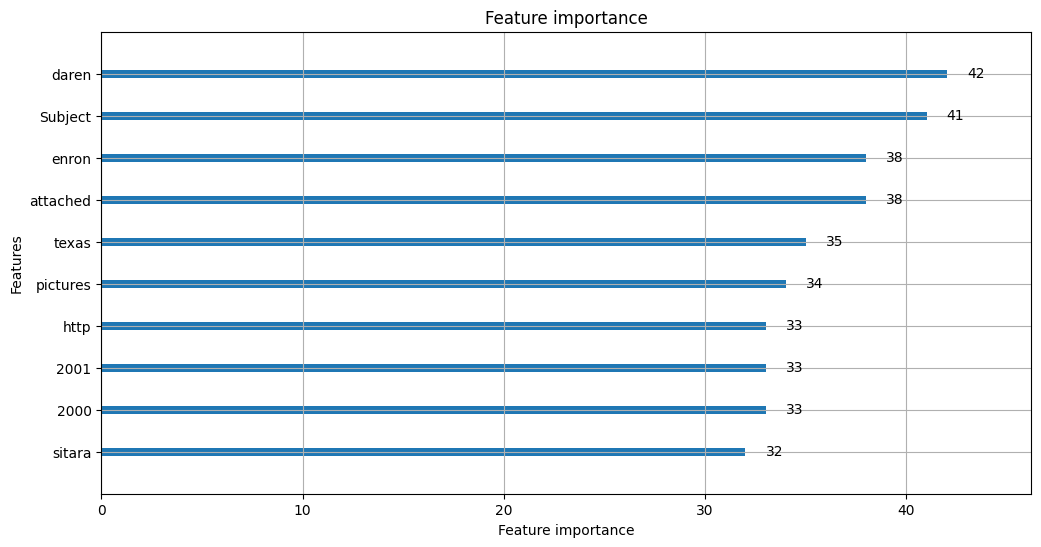

In [28]:
import matplotlib.pyplot as plt
lgb.plot_importance(gbm, figsize=(12, 6), max_num_features=10)
plt.show()

ちゃんとしているメールは件名がしっかり描かれている
スパムメールは件名が書かれていないんじゃないか

In [29]:
spam_rows = (df.label == '1')
spam_data = df[spam_rows]

count = 0
for i in spam_data['text']:
    count = count + i.count('subject')

print(count)

160


In [30]:
legit_rows = (df.label == '0')
legit_data = df[legit_rows]

count = 0
for i in legit_data['text']:
    count = count + i.count('subject')

print(count)

2733


迷惑メールデータセットでは「subject」の出現頻度が迷惑メールで160、非迷惑メールで2733と大きく差がある。これは特定の非迷惑メールに「subject」が多く含まれている影響と考えられる。このような特徴の偏りを攻撃者が把握すると、「subject」を多用した迷惑メールを送ることで検出を回避できる可能性がある。つまり、機械学習ベースの検出器は特徴量やアルゴリズムを知られると誤判定を誘発される危険があり、これはホワイトボックス攻撃に該当する。

In [32]:
from google.colab import files
uploaded = files.upload()


KeyboardInterrupt: 

In [ ]:
import pandas as pd
df = pd.read_csv('spam_collection.csv')


In [31]:
import pandas as pd

# Assuming the data is in a CSV file named 'spam_collection.csv'
df = pd.read_csv('spam_collection.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'spam_collection.csv'